In [1]:
import pandas as pd
import numpy as np
# Read the CSV file
# df = pd.read_csv(r"C:\Users\Administrator\Desktop\AI-Portfolio\Deep-Learning\accepted_2007_to_2018Q4.csv",
#     low_memory=False
# )

# # Save as Parquet
# df.to_parquet(
#     r"C:\Users\Administrator\Desktop\AI-Portfolio\Deep-Learning\lendingclubfull.parquet",
#     engine="pyarrow",
#     compression="snappy",
#     index=False
# )

# print("Conversion completed successfully!")

In [3]:
df= pd.read_parquet(r'C:\Users\Administrator\Desktop\AI-Portfolio\Deep-Learning\lendingclubfull.parquet')

In [4]:
pd.set_option('display.max_columns', None)

In [5]:
df.shape

(2260701, 151)

In [6]:
df['diff'] = (df['issue_d'] < df['last_credit_pull_d']).astype(int)
df['diff'].sum()

np.int64(1376339)

In [13]:
# Checking on default pattern by vintage to see if the training data need to be split basis years

df['issue_year'] = pd.to_datetime(df['issue_d']).dt.year
vintage_summary = df.groupby('issue_year').agg(
    Total   = ('Y', 'count'),
    Defaults= ('Y', 'sum'),
    NaN_cnt = ('Y', lambda x: x.isna().sum())
).assign(Default_Rate = lambda x: x['Defaults'] / x['Total'] * 100)

print(vintage_summary)

C:\Users\Administrator\AppData\Local\Temp\ipykernel_16008\3992731500.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['issue_year'] = pd.to_datetime(df['issue_d']).dt.year


             Total  Defaults  NaN_cnt  Default_Rate
issue_year                                         
2007.0         251      45.0      352     17.928287
2008.0        1562     247.0      831     15.813060
2009.0        4716     594.0      565     12.595420
2010.0       11536    1487.0     1001     12.890083
2011.0       21721    3297.0        0     15.178859
2012.0       53367    8644.0        0     16.197275
2013.0      134807   21027.0        7     15.597855
2014.0      223436   41495.0    12193     18.571313
2015.0      376904   77162.0    44191     20.472587
2016.0      297641   72788.0   136766     24.454964
2017.0      177304   47152.0   266275     26.593873
2018.0       63532   16088.0   431710     25.322672


In [14]:
# Variables which are futuristic viz. Hardship and Settlement. Bureau variables with keywords like Last, Recent, Current have been removed 
# as last Bureau pull date is greater than the loan account open date for approx. 65% of accounts

future_var= ['acc_now_delinq','avg_cur_bal','bc_util','collection_recovery_fee','delinq_amnt', 'funded_amnt','funded_amnt_inv','initial_list_status',
             'installment','int_rate','issue_d','last_credit_pull_d','last_fico_range_high','last_fico_range_low','last_pymnt_amnt','last_pymnt_d',
             'loan_status','max_bal_bc','mo_sin_rcnt_rev_tl_op','mo_sin_rcnt_tl','mths_since_last_major_derog','mths_since_rcnt_il','mths_since_recent_bc',
             'mths_since_recent_bc_dlq','mths_since_recent_inq','mths_since_recent_revol_delinq','next_pymnt_d','num_actv_bc_tl','num_actv_rev_tl',
             'num_tl_120dpd_2m','num_tl_30dpd','open_act_il','out_prncp','out_prncp_inv','policy_code','pymnt_plan','recoveries','term','tot_cur_bal',
             'total_acc','total_bal_il','total_pymnt','total_pymnt_inv','total_rec_int','total_rec_late_fee','total_rec_prncp','hardship_flag','hardship_type',
             'hardship_reason','hardship_status','deferral_term','hardship_amount','hardship_start_date','hardship_end_date','payment_plan_start_date',
             'hardship_length','hardship_dpd','hardship_loan_status','orig_projected_additional_accrued_interest','hardship_payoff_balance_amount',
             'hardship_last_payment_amount','disbursement_method','debt_settlement_flag','debt_settlement_flag_date','settlement_status',
             'settlement_date','settlement_amount','settlement_percentage','settlement_term', 'mths_since_last_record','mths_since_last_delinq'] 

In [9]:
# Variables which are discarded based on judgement 

disc_var= ['bc_open_to_buy','desc','earliest_cr_line','grade','inq_fi','inq_last_6mths','mo_sin_old_il_acct','mo_sin_old_rev_tl_op','num_bc_sats',
           'num_rev_tl_bal_gt_0','num_sats','open_acc','open_acc_6m','pct_tl_nvr_dlq','url','verified_status_joint','sec_app_earliest_cr_line ',
           'sec_app_revol_util ']

In [10]:
# Variables considered for 1st round of scrutiny

cons_var=['acc_open_past_24mths','addr_state','all_util','annual_inc','annual_inc_joint','application_type','chargeoff_within_12_mths',
          'collections_12_mths_ex_med','delinq_2yrs','dti','dti_joint','emp_length','emp_title','fico_range_high','fico_range_low',
          'home_ownership','id','il_util','inq_last_12m','loan_amnt','member_id','mort_acc',
          'num_accts_ever_120_pd','num_bc_tl','num_il_tl','num_op_rev_tl','num_rev_accts','num_tl_90g_dpd_24m','num_tl_op_past_12m','open_il_12m',
          'open_il_24m','open_rv_12m','open_rv_24m','percent_bc_gt_75','pub_rec','pub_rec_bankruptcies','purpose','revol_bal','revol_util',
          'sub_grade','tax_liens','title','tot_coll_amt','tot_hi_cred_lim','total_bal_ex_mort','total_bc_limit','total_cu_tl',
          'total_il_high_credit_limit','total_rev_hi_lim','verification_status','zip_code','revol_bal_joint','sec_app_fico_range_low',
          'sec_app_fico_range_high','sec_app_inq_last_6mths','sec_app_mort_acc','sec_app_open_acc','sec_app_open_act_il','sec_app_num_rev_accts',
          'sec_app_chargeoff_within_12_mths','sec_app_collections_12_mths_ex_med','sec_app_mths_since_last_major_derog', 'Y']


In [11]:
df['Y']= df['loan_status'].map({
    'Fully Paid': 0, 
    'Charged Off': 1,
    'Late (31-120 days)': 1})                            

In [12]:
df['Y'].value_counts(dropna=False).sort_values()

Y
1.0     290026
NaN     893924
0.0    1076751
Name: count, dtype: int64

In [15]:
df1=df[cons_var].copy()

In [16]:
# Feature Engineering

df1['total_inc']= df1['annual_inc_joint'].fillna(df1['annual_inc'])
df1['tot_chargeoff_within_12_mths'] = (df1['chargeoff_within_12_mths'] + df1['sec_app_chargeoff_within_12_mths'].fillna(0))
df1['tot_dti'] = df1['dti_joint'].fillna(df1['dti'])
df1['fico_avg'] = (df1['fico_range_low'] + df1['fico_range_high'])/2
df1['tot_limit']= df1['tot_hi_cred_lim']
df1['tot_unsec_limit']= df1['total_il_high_credit_limit'] + df1['total_rev_hi_lim']
df1['tot_sec_limit'] = df1['tot_hi_cred_lim'] - df1['tot_unsec_limit']
df1['tot_sec_limit'] = np.where(df1['tot_sec_limit'] < 0, 0, df1['tot_sec_limit'])
df1['tot_acct']= df1['num_il_tl'] + df1['num_rev_accts'].fillna(0) + df1['mort_acc']
df1['tot_unsec_acct'] = df1['num_il_tl'] + df1['num_rev_accts'].fillna(0)
df1['tot_sec_acct']= df1['mort_acc']
# Total Balance cannot be derived as "all_util" only contains 1lakh records, hence, total_util and Secured_util also can't be derived
df1['tot_unsec_util'] = df1['total_bal_ex_mort']/ df1['tot_unsec_limit']*100
df1['tot_unsec_util']= df1['tot_unsec_util'].fillna(0)
df1['tot_unsec_bal'] = df1['total_bal_ex_mort']
df1['Num_30DPD_2yrs'] = df1['delinq_2yrs']
df1['Num_90DPD_2yrs'] = df1['num_tl_90g_dpd_24m']
df1['num_acc_op_past_12m']= df1['num_tl_op_past_12m']
df1['num_acc_op_past_24mths'] = df1['acc_open_past_24mths']
df1['emp_length_num'] = df['emp_length'].map(
{   '< 1 year': 0,
    '1 year': 1,
    '2 years': 2,
    '3 years': 3,
    '4 years': 4,
    '5 years': 5,
    '6 years': 6,
    '7 years': 7,
    '8 years': 8,
    '9 years': 9,
    '10+ years': 10})

df1['zip_code'] = df1['zip_code'].map(df1['zip_code'].value_counts(normalize=True))


In [17]:
# Dropping variables at Pre-model stage

df1=df1.drop(['addr_state','application_type', 'emp_title','id','member_id','tax_liens','title','sec_app_mort_acc','sec_app_open_acc',
          'sec_app_open_act_il','sec_app_num_rev_accts','sec_app_collections_12_mths_ex_med','sec_app_mths_since_last_major_derog',
          'sec_app_inq_last_6mths','num_bc_tl','num_op_rev_tl','open_il_12m','open_il_24m','open_rv_12m','open_rv_24m','pub_rec',
          'revol_bal','total_bc_limit','total_cu_tl','revol_bal_joint','sec_app_fico_range_low','sec_app_fico_range_high',
          'chargeoff_within_12_mths','sec_app_chargeoff_within_12_mths','fico_range_high','fico_range_low','annual_inc',
          'annual_inc_joint','dti','dti_joint','mort_acc','num_il_tl','num_rev_accts', 'total_rev_hi_lim','total_il_high_credit_limit',
          'tot_hi_cred_lim','il_util','revol_util','all_util','total_bal_ex_mort','delinq_2yrs','num_tl_90g_dpd_24m', 'percent_bc_gt_75', 
            'emp_length','num_tl_op_past_12m','acc_open_past_24mths', 'sub_grade'], axis= 1)

In [18]:
# Keeping entries where Target Variable Y is not null
df1 = df1.loc[df1['Y'].notnull()]

# Records which have null records for tot_limit, Unsec_limit, Sec_limit, total_accounts and as such does not contain any separation info
df1 = df1.dropna(subset=['tot_limit'])

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.utils.class_weight import compute_class_weight

df1['inq_last_12m_missing'] = df1['inq_last_12m'].isna().astype(int)
df1['emp_length_missing'] = df1['emp_length_num'].isna().astype(int)
df1['tot_unsec_util_gt_100'] = (df1['tot_unsec_util'] > 100).astype(int)


x= df1.drop('Y', axis= 1)
y= df1['Y']

x_train, x_test, y_train, y_test= train_test_split(x,y, test_size= 0.2, random_state= 42, stratify= y)

emp_length_median = x_train['emp_length_num'].median()
x_train['emp_length_num']= x_train['emp_length_num'].fillna(emp_length_median)
x_test['emp_length_num']= x_test['emp_length_num'].fillna(emp_length_median)

inq_last_12m_median = x_train['inq_last_12m'].median()
x_train['inq_last_12m']= x_train['inq_last_12m'].fillna(inq_last_12m_median)
x_test['inq_last_12m']= x_test['inq_last_12m'].fillna(inq_last_12m_median)

x_train['tot_unsec_util'] = x_train['tot_unsec_util'].clip(upper=100)
x_test['tot_unsec_util'] = x_test['tot_unsec_util'].clip(upper=100)

# handling outlier values in numerical columns by log converting them

log_scale_cols= ['loan_amnt','tot_coll_amt','total_inc','tot_limit','tot_unsec_limit','tot_sec_limit','tot_unsec_bal']

for i in log_scale_cols:
    x_train[i]= np.log1p(x_train[i])
    x_test[i]= np.log1p(x_test[i])

# grades = ['A1','A2','A3','A4','A5','B1','B2','B3','B4','B5','C1','C2','C3','C4','C5','D1','D2','D3','D4','D5','E1','E2','E3','E4','E5',
#           'F1','F2','F3','F4','F5','G1','G2','G3','G4','G5']

# ord_encoder = OrdinalEncoder(categories=[grades])

# x_train['sub_grade'] = (ord_encoder.fit_transform(x_train[['sub_grade']]).astype(int) + 1)
# x_test['sub_grade'] = (ord_encoder.transform(x_test[['sub_grade']]).astype(int) + 1)

# Converting categorical variables to one_hot_encoding

one_hot_cols = ['home_ownership', 'purpose', 'verification_status']

x_train = pd.get_dummies(x_train, columns=one_hot_cols, drop_first=True, dtype=int)
x_test = pd.get_dummies(x_test, columns=one_hot_cols, drop_first=True, dtype=int)

x_test = x_test.reindex(columns=x_train.columns, fill_value=0)

# Scaling remaining variables

stan_scale_cols=['collections_12_mths_ex_med', 'inq_last_12m',
       'loan_amnt', 'num_accts_ever_120_pd',
       'pub_rec_bankruptcies','tot_coll_amt',
       'total_inc', 'tot_chargeoff_within_12_mths', 'tot_dti', 'fico_avg',
       'tot_limit', 'tot_unsec_limit', 'tot_sec_limit', 'tot_acct',
       'tot_unsec_acct', 'tot_sec_acct', 'tot_unsec_util', 'tot_unsec_bal',
       'Num_30DPD_2yrs', 'Num_90DPD_2yrs', 'num_acc_op_past_12m',
       'num_acc_op_past_24mths', 'emp_length_num' 
        ]

scaler = StandardScaler()

x_train[stan_scale_cols] = scaler.fit_transform(x_train[stan_scale_cols])
x_test[stan_scale_cols] = scaler.transform(x_test[stan_scale_cols])


In [128]:
from sklearn.tree import DecisionTreeClassifier
model= DecisionTreeClassifier()

model.fit(x_train,y_train)
importance=pd.Series(model.feature_importances_, index= x_train.columns)
importance.sort_values(ascending= False)

tot_dti                                0.094958
zip_code                               0.079389
tot_unsec_util                         0.075419
total_inc                              0.069112
loan_amnt                              0.065372
tot_limit                              0.064223
tot_unsec_bal                          0.062433
tot_unsec_limit                        0.058179
fico_avg                               0.046048
tot_acct                               0.040967
tot_unsec_acct                         0.039700
num_acc_op_past_24mths                 0.035420
emp_length_num                         0.033276
tot_sec_limit                          0.029185
num_acc_op_past_12m                    0.026685
tot_sec_acct                           0.020962
tot_coll_amt                           0.018905
inq_last_12m                           0.016671
num_accts_ever_120_pd                  0.015113
Num_30DPD_2yrs                         0.012766
pub_rec_bankruptcies                   0

In [130]:
from sklearn.linear_model import Lasso
model=Lasso(alpha= 0.001)
model.fit(x_train, y_train)

importance=pd.Series(model.coef_, index= x_train.columns)
importance.sort_values(ascending= False)

loan_amnt                              0.061934
tot_dti                                0.045640
emp_length_missing                     0.044480
num_acc_op_past_24mths                 0.035200
tot_unsec_util                         0.026505
verification_status_Verified           0.022311
home_ownership_RENT                    0.020670
verification_status_Source Verified    0.016591
num_acc_op_past_12m                    0.011623
Num_30DPD_2yrs                         0.010444
inq_last_12m                           0.004101
collections_12_mths_ex_med             0.002217
tot_chargeoff_within_12_mths           0.001021
home_ownership_OTHER                  -0.000000
purpose_home_improvement              -0.000000
purpose_major_purchase                 0.000000
pub_rec_bankruptcies                  -0.000000
home_ownership_OWN                     0.000000
home_ownership_NONE                   -0.000000
purpose_medical                        0.000000
tot_unsec_util_gt_100                  0

In [131]:
comb_train = pd.concat([x_train, y_train], axis=1)
comb_train.corr()['Y'].sort_values(ascending=False)

Y                                      1.000000
tot_dti                                0.107738
num_acc_op_past_24mths                 0.099932
num_acc_op_past_12m                    0.085414
loan_amnt                              0.074341
home_ownership_RENT                    0.069886
tot_unsec_util                         0.067702
verification_status_Verified           0.065125
inq_last_12m                           0.046371
emp_length_missing                     0.044045
purpose_debt_consolidation             0.032789
purpose_small_business                 0.026087
pub_rec_bankruptcies                   0.024154
tot_coll_amt                           0.020337
verification_status_Source Verified    0.019129
Num_30DPD_2yrs                         0.018853
collections_12_mths_ex_med             0.016464
num_accts_ever_120_pd                  0.011358
Num_90DPD_2yrs                         0.009915
purpose_other                          0.009230
tot_chargeoff_within_12_mths           0

In [132]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler() #Minmax Scaler used to avoid negative values. chisquare test does not work on negative values.
x_scaled = scaler.fit_transform(x_train)
x_scaled = pd.DataFrame(x_scaled, columns=x_train.columns)

In [133]:
from sklearn.feature_selection import chi2

chi_scores, p_values = chi2(x_scaled, y_train)

chi_df = pd.DataFrame({
    "Feature": x_scaled.columns,
    "Chi2 Score": chi_scores,
    "P-value": p_values
}).sort_values(by="Chi2 Score", ascending=False)

chi_df

,Feature,Chi2 Score,P-value
31,home_ownership_RENT,3077.443630,0.000000e+00
45,verification_status_Verified,3043.684689,0.000000e+00
27,home_ownership_MORTGAGE,2723.680705,0.000000e+00
24,inq_last_12m_missing,2551.643705,0.000000e+00
13,tot_sec_limit,2532.581957,0.000000e+00
10,fico_avg,2519.681954,0.000000e+00
25,emp_length_missing,1894.767352,0.000000e+00
32,purpose_credit_card,1481.005821,0.000000e+00
41,purpose_small_business,700.261493,2.623257e-154
9,tot_dti,668.250475,2.399252e-147


In [22]:
# Dropping redundant variables as identified through feature selection techniques

cols_to_drop = [
    'purpose_home_improvement', 'purpose_major_purchase',
    'purpose_medical', 'purpose_moving',
    'pub_rec_bankruptcies', 'purpose_other',
    'purpose_renewable_energy', 'purpose_small_business',
    'purpose_vacation', 'purpose_wedding',
    'purpose_house', 'home_ownership_OTHER',
    'home_ownership_OWN', 'home_ownership_NONE',
    'tot_unsec_util_gt_100', 'tot_coll_amt'
]

x_train = x_train.drop(columns=cols_to_drop, axis=1)
x_test = x_test.drop(columns=cols_to_drop, axis=1)

In [20]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

from scikeras.wrappers import KerasClassifier


def create_model(learning_rate=0.001,dropout_rate=0.1, neurons1=256, neurons2=128, neurons3=64):

    model = Sequential([
        tf.keras.layers.Input(shape=(x_train.shape[1],)),  

        # Block 1
        Dense(neurons1, activation='relu'),
        BatchNormalization(),
        Dropout(dropout_rate),
        
        # Block 2
        Dense(neurons2, activation='relu'),
        BatchNormalization(),
        Dropout(dropout_rate),
        
        # Block 3
        Dense(neurons3, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        
        # Output
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=Adam(learning_rate= learning_rate),
        loss='binary_crossentropy',
        metrics=[
            tf.keras.metrics.AUC(name='AUC'),
            tf.keras.metrics.Recall(name='Recall'),
            tf.keras.metrics.Precision(name='Precision'),
            tf.keras.metrics.F1Score(name='F1', threshold=0.5)
        ]
    )

    return model

early_stop = EarlyStopping(
    monitor='val_AUC',
    mode= 'max',
    patience=6,
    restore_best_weights=True
)

# weights = compute_class_weight(
#     class_weight='balanced',
#     classes=np.unique(y_train),
#     y=y_train)

# class_weights = dict(zip(np.unique(y_train), weights))

model = KerasClassifier(
    model=create_model,
    optimizer= 'adam',
    loss="binary_crossentropy",
    epochs=40,
    batch_size=256,
    verbose=1,
    callbacks=[early_stop],
    class_weight= {0: 1, 1: 3},
    validation_split=0.2)

model.fit(x_train, y_train)

Epoch 1/40
3249/3249 ━━━━━━━━━━━━━━━━━━━━ 33s 9ms/step - AUC: 0.6812 - F1: 0.4191 - Precision: 0.3396 - Recall: 0.5472 - loss: 0.9157 - val_AUC: 0.6938 - val_F1: 0.4305 - val_Precision: 0.3476 - val_Recall: 0.5652 - val_loss: 0.9001
Epoch 2/40
3249/3249 ━━━━━━━━━━━━━━━━━━━━ 27s 8ms/step - AUC: 0.6962 - F1: 0.4310 - Precision: 0.3520 - Recall: 0.5556 - loss: 0.8972 - val_AUC: 0.6966 - val_F1: 0.4288 - val_Precision: 0.3585 - val_Recall: 0.5333 - val_loss: 0.8969
Epoch 3/40
3249/3249 ━━━━━━━━━━━━━━━━━━━━ 29s 9ms/step - AUC: 0.6985 - F1: 0.4330 - Precision: 0.3548 - Recall: 0.5557 - loss: 0.8949 - val_AUC: 0.6979 - val_F1: 0.4357 - val_Precision: 0.3409 - val_Recall: 0.6034 - val_loss: 0.8968
Epoch 4/40
3249/3249 ━━━━━━━━━━━━━━━━━━━━ 26s 8ms/step - AUC: 0.6995 - F1: 0.4344 - Precision: 0.3549 - Recall: 0.5597 - loss: 0.8941 - val_AUC: 0.6977 - val_F1: 0.4319 - val_Precision: 0.3568 - val_Recall: 0.5471 - val_loss: 0.8968
Epoch 5/40
3249/3249 ━━━━━━━━━━━━━━━━━━━━ 29s 9ms/step - AUC: 0.7005

KerasClassifier(
	model=<function create_model at 0x0000017369062840>
	build_fn=None
	warm_start=False
	random_state=None
	optimizer=adam
	loss=binary_crossentropy
	metrics=None
	batch_size=256
	validation_batch_size=None
	verbose=1
	callbacks=[<keras.src.callbacks.early_stopping.EarlyStopping object at 0x0000017368F5F0E0>]
	validation_split=0.2
	shuffle=True
	run_eagerly=False
	epochs=40
	class_weight={0: 1, 1: 3}
)

In [21]:
# one record of x_test was null, replaced it with zero

x_test['zip_code']= x_test['zip_code'].fillna(0)
x_test.isnull().sum()

collections_12_mths_ex_med             0
inq_last_12m                           0
loan_amnt                              0
num_accts_ever_120_pd                  0
pub_rec_bankruptcies                   0
tot_coll_amt                           0
zip_code                               0
total_inc                              0
tot_chargeoff_within_12_mths           0
tot_dti                                0
fico_avg                               0
tot_limit                              0
tot_unsec_limit                        0
tot_sec_limit                          0
tot_acct                               0
tot_unsec_acct                         0
tot_sec_acct                           0
tot_unsec_util                         0
tot_unsec_bal                          0
Num_30DPD_2yrs                         0
Num_90DPD_2yrs                         0
num_acc_op_past_12m                    0
num_acc_op_past_24mths                 0
emp_length_num                         0
inq_last_12m_mis

In [27]:
# Prediction on test dataset
y_pred = model.predict(x_test)

1016/1016 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


In [28]:
y_proba = model.predict_proba(x_test)[:, 1]

1016/1016 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


In [29]:
from sklearn.metrics import roc_auc_score
nn_auc= roc_auc_score(y_test, y_proba)

In [30]:
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("AUC Score:", roc_auc_score(y_test, y_proba))

Accuracy: 0.6895093323071002
Precision: 0.35625384946136596
Recall: 0.547996138858103
F1 Score: 0.4317959336023607
Confusion Matrix:
 [[148513  55395]
 [ 25286  30656]]
AUC Score: 0.6992571023626251


In [36]:
# Cross Validation using StratfiedKFold

from sklearn.model_selection import StratifiedKFold, cross_val_score
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

score= cross_val_score(model, x_train, y_train, cv=cv, scoring='roc_auc')
print('cross_val_score:', score)
print('Mean:', score.mean())

Epoch 1/40
2599/2599 ━━━━━━━━━━━━━━━━━━━━ 44s 14ms/step - AUC: 0.6790 - F1: 0.4173 - Precision: 0.3374 - Recall: 0.5468 - loss: 0.9171 - val_AUC: 0.6932 - val_F1: 0.4261 - val_Precision: 0.3542 - val_Recall: 0.5345 - val_loss: 0.9006
Epoch 2/40
2599/2599 ━━━━━━━━━━━━━━━━━━━━ 36s 14ms/step - AUC: 0.6946 - F1: 0.4298 - Precision: 0.3509 - Recall: 0.5542 - loss: 0.8987 - val_AUC: 0.6950 - val_F1: 0.4316 - val_Precision: 0.3476 - val_Recall: 0.5691 - val_loss: 0.8990
Epoch 3/40
2599/2599 ━━━━━━━━━━━━━━━━━━━━ 35s 13ms/step - AUC: 0.6960 - F1: 0.4312 - Precision: 0.3523 - Recall: 0.5558 - loss: 0.8973 - val_AUC: 0.6953 - val_F1: 0.4296 - val_Precision: 0.3497 - val_Recall: 0.5570 - val_loss: 0.8981
Epoch 4/40
2599/2599 ━━━━━━━━━━━━━━━━━━━━ 24s 9ms/step - AUC: 0.6977 - F1: 0.4326 - Precision: 0.3536 - Recall: 0.5572 - loss: 0.8959 - val_AUC: 0.6958 - val_F1: 0.4291 - val_Precision: 0.3554 - val_Recall: 0.5415 - val_loss: 0.8979
Epoch 5/40
2599/2599 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - AUC: 0.6

In [31]:
import numpy as np
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

# Ignore divide-by-zero warnings
with np.errstate(divide='ignore', invalid='ignore'):
    f1_scores = 2 * precision * recall / (precision + recall)

# Replace NaN with 0
f1_scores = np.nan_to_num(f1_scores)

# Ignore last element because thresholds is shorter
best_idx = np.argmax(f1_scores[:-1])

best_threshold = thresholds[best_idx]

print(f"Optimal Threshold: {best_threshold:.4f}")
print(f"Best F1 Score: {f1_scores[best_idx]:.4f}")

Optimal Threshold: 0.4568
Best F1 Score: 0.4377


In [31]:
# Checking Score, using optimal Y threshold obtained in the above step
y_pred= (y_proba >= 0.45).astype(int)

In [32]:
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("AUC Score:", roc_auc_score(y_test, y_proba))

Accuracy: 0.6429478545314604
Precision: 0.33119799112870707
Recall: 0.6460083658074435
F1 Score: 0.4378945582764846
Confusion Matrix:
 [[130931  72977]
 [ 19803  36139]]
AUC Score: 0.6994726154161723


In [31]:
# Hyperparameter tuning continued, checking for best hyper parameteres using Grid Search
# Hyperparameter tuning continued...

from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold
import numpy as np

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grid = {
    'model__learning_rate': [0.0005, 0.001],
    'class_weight' : [
        {0: 1, 1: 1},
        {0: 1, 1: 2},
        {0: 1, 1: 3}
    ]
}


grid_search = GridSearchCV(
    estimator= model, 
    param_grid=param_grid, 
    cv=cv, 
    scoring= 'f1',        
    verbose=2,           
    n_jobs=-1            
)

print("Starting Grid Search... This may take a while depending on your hardware.")
grid_search.fit(x_train, y_train)

print("\n--- Grid Search Complete ---")
print(f"Best Parameters found: {grid_search.best_params_}")
print(f"Best Cross-Validation AUC-Score: {grid_search.best_score_:.4f}")

best_pipeline = grid_search.best_estimator_

Starting Grid Search... This may take a while depending on your hardware.
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Epoch 1/40
986/986 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - AUC: 0.6601 - F1: 0.3941 - Precision: 0.3140 - Recall: 0.5292 - loss: 0.9294 - val_AUC: 0.6926 - val_F1: 0.4162 - val_Precision: 0.3472 - val_Recall: 0.5195 - val_loss: 0.8882
Epoch 2/40
986/986 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - AUC: 0.6909 - F1: 0.4160 - Precision: 0.3442 - Recall: 0.5256 - loss: 0.8890 - val_AUC: 0.6961 - val_F1: 0.4230 - val_Precision: 0.3433 - val_Recall: 0.5507 - val_loss: 0.8851
Epoch 3/40
986/986 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - AUC: 0.6949 - F1: 0.4184 - Precision: 0.3462 - Recall: 0.5285 - loss: 0.8855 - val_AUC: 0.6970 - val_F1: 0.4163 - val_Precision: 0.3524 - val_Recall: 0.5084 - val_loss: 0.8843
Epoch 4/40
986/986 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - AUC: 0.6969 - F1: 0.4200 - Precision: 0.3469 - Recall: 0.5321 - loss: 0.8838 - val_AUC: 0.6949 - val_F1: 0.4141 - val_P

In [34]:
# Fitting Extreme gradient boosting as a surrogate for NN to calculate shap values as calculating shap with NN is very slow.

import xgboost as xgb
from sklearn.metrics import roc_auc_score
print("Training XGBoost surrogate...")

xgb_model = xgb.XGBClassifier(
    n_estimators     = 1000,
    max_depth        = 6,
    learning_rate    = 0.05,
    min_child_weight    = 50, 
    subsample        = 0.8,
    colsample_bytree = 0.8,
    scale_pos_weight = 3,       # mirrors {0:1, 1:3} class weight obtained in Grid Search CV
    tree_method= 'hist',
    eval_metric      = 'auc',
    early_stopping_rounds = 50,
    random_state     = 42,
    verbosity        = 0
)

xgb_model.fit(
    x_train, y_train,
    eval_set    = [(x_test, y_test)],
    verbose     = 50
)

xgb_proba   = xgb_model.predict_proba(x_test)[:, 1]
xgb_auc     = roc_auc_score(y_test, xgb_proba)

print(f"\nNeural Network AUC : {nn_auc:.4f}")
print(f"XGBoost AUC        : {xgb_auc:.4f}")
print(f"Difference         : {xgb_auc - nn_auc:+.4f}")

Training XGBoost surrogate...
[0]	validation_0-auc:0.64975
[50]	validation_0-auc:0.68718
[100]	validation_0-auc:0.69372
[150]	validation_0-auc:0.69627
[200]	validation_0-auc:0.69792
[250]	validation_0-auc:0.69889
[300]	validation_0-auc:0.69972
[350]	validation_0-auc:0.70031
[400]	validation_0-auc:0.70070
[450]	validation_0-auc:0.70102
[500]	validation_0-auc:0.70129
[550]	validation_0-auc:0.70155
[600]	validation_0-auc:0.70173
[650]	validation_0-auc:0.70193
[700]	validation_0-auc:0.70213
[750]	validation_0-auc:0.70226
[800]	validation_0-auc:0.70236
[850]	validation_0-auc:0.70244
[900]	validation_0-auc:0.70247
[950]	validation_0-auc:0.70251
[999]	validation_0-auc:0.70254

Neural Network AUC : 0.6995
XGBoost AUC        : 0.7025
Difference         : +0.0031


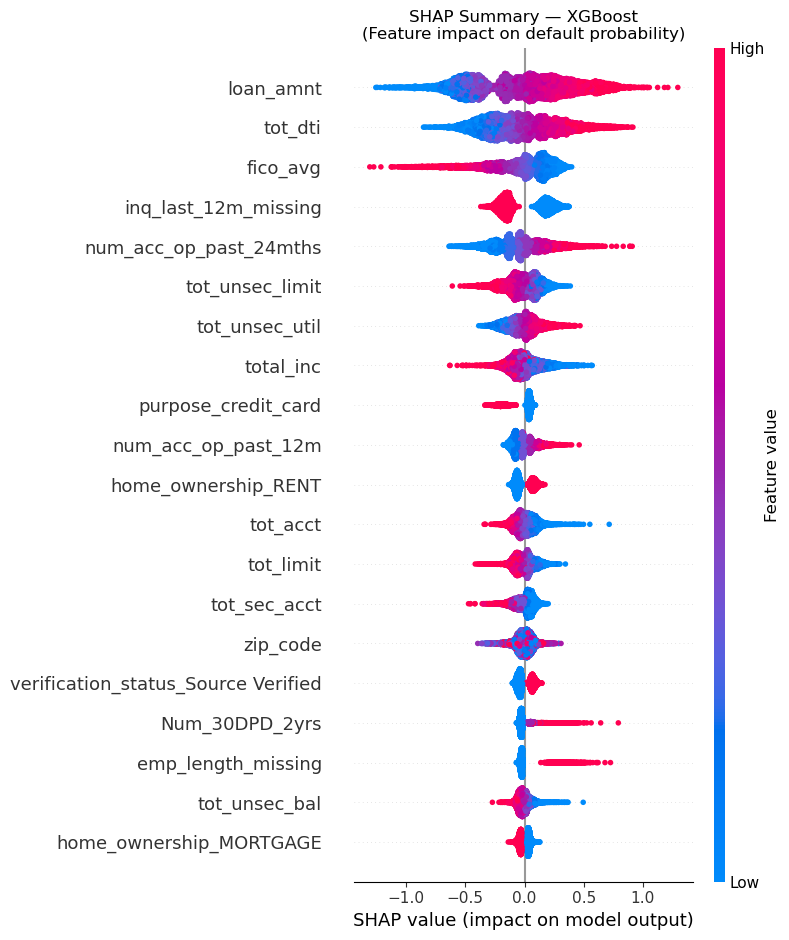

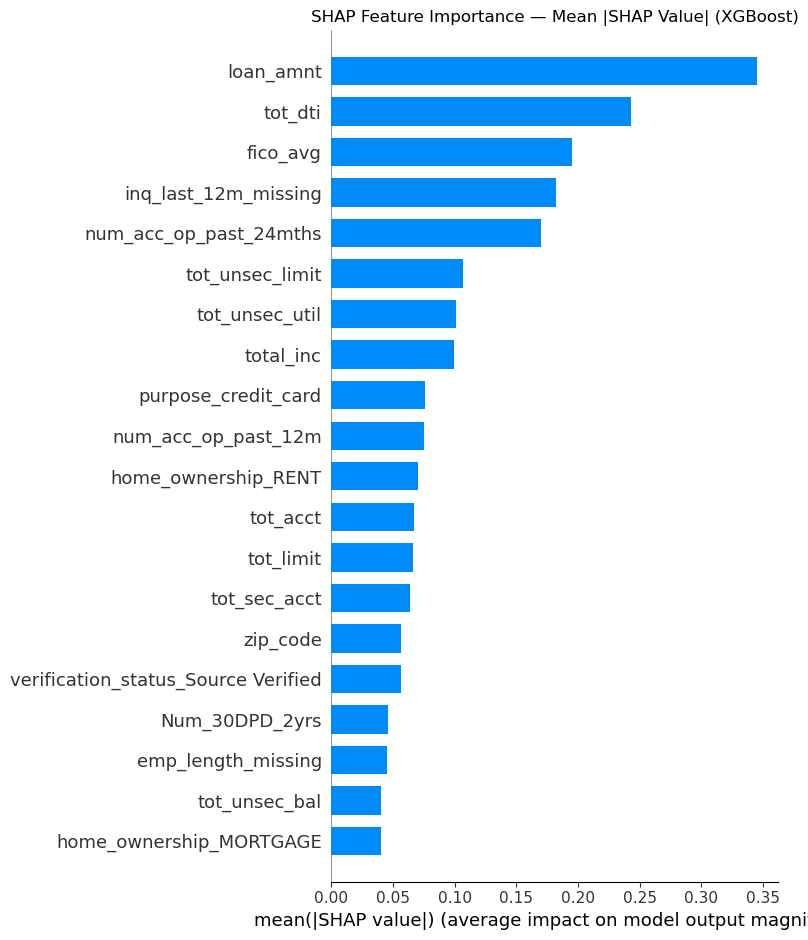


Top 15 Features by SHAP Importance (XGBoost):
 Rank                Feature  Mean_Abs_SHAP
    1              loan_amnt       0.345267
    2                tot_dti       0.243160
    3               fico_avg       0.195311
    4   inq_last_12m_missing       0.182366
    5 num_acc_op_past_24mths       0.170349
    6        tot_unsec_limit       0.106673
    7         tot_unsec_util       0.100890
    8              total_inc       0.099354
    9    purpose_credit_card       0.076236
   10    num_acc_op_past_12m       0.074935
   11    home_ownership_RENT       0.069895
   12               tot_acct       0.066534
   13              tot_limit       0.066052
   14           tot_sec_acct       0.063431
   15               zip_code       0.056229
  XGBoost is used as a high-fidelity surrogate
  because TreeExplainer requires tree-based models.


In [39]:
# TreeExplainer on XGBoost and Shap values

x_test_sample = x_test.sample(10000, random_state=42)

explainer_xgb   = shap.TreeExplainer(xgb_model)
shap_values_xgb = explainer_xgb.shap_values(x_test_sample)

# ── Plot 1: Beeswarm ──────────────────────────────────────────────────────────
x_test_sample[stan_scale_cols] = scaler.inverse_transform(x_test_sample[stan_scale_cols])

plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values_xgb,
    x_test_sample,
    feature_names=x_test.columns.tolist(),
    plot_type='dot',
    max_display=20,
    show=False
)
plt.title('SHAP Summary — XGBoost\n(Feature impact on default probability)',fontsize=12)
plt.tight_layout()
plt.savefig('shap_xgb_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Plot 2: Bar ───────────────────────────────────────────────────────────────
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values_xgb,
    x_test_sample,
    feature_names=x_test.columns.tolist(),
    plot_type='bar',
    max_display=20,
    show=False
)
plt.title('SHAP Feature Importance — Mean |SHAP Value| (XGBoost)', fontsize=12)
plt.tight_layout()
plt.savefig('shap_xgb_bar.png', dpi=150, bbox_inches='tight')
plt.show()

# ── SHAP importance table ─────────────────────────────────────────────────────
shap_importance = pd.DataFrame({
    'Feature'       : x_test.columns.tolist(),
    'Mean_Abs_SHAP' : np.abs(shap_values_xgb).mean(axis=0)
}).sort_values('Mean_Abs_SHAP', ascending=False).reset_index(drop=True)

shap_importance['Rank'] = shap_importance.index + 1

print("\nTop 15 Features by SHAP Importance (XGBoost):")
print(shap_importance[['Rank', 'Feature', 'Mean_Abs_SHAP']].head(15).to_string(index=False))

# ── Model comparison summary ──────────────────────────────────────────────────
print("  XGBoost is used as a high-fidelity surrogate")
print("  because TreeExplainer requires tree-based models.")

KS Statistic : 28.85%
P-value      : 0.0000


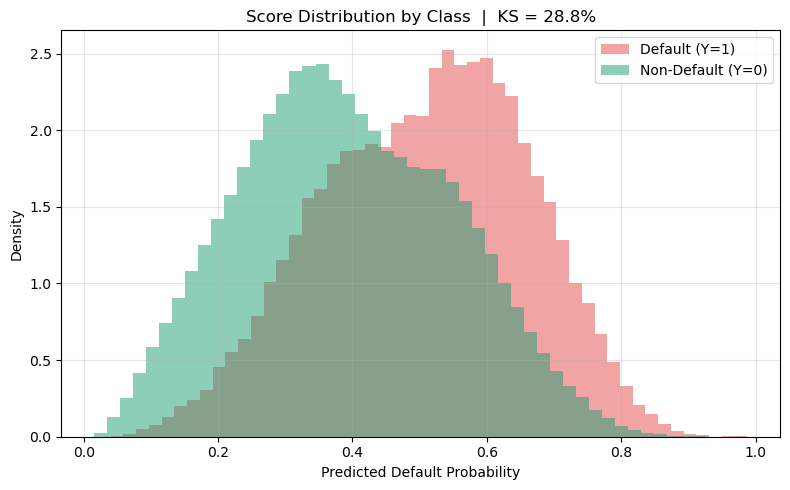

In [40]:
# ── KS Statistic ──────────────────────────────────────────────────────────────
from scipy.stats import ks_2samp
import matplotlib.pyplot as plt

# Separate scores by actual class
default_scores    = y_proba[y_test == 1]
non_default_scores= y_proba[y_test == 0]

# KS statistic
ks_stat, ks_pvalue = ks_2samp(default_scores, non_default_scores)
print(f"KS Statistic : {ks_stat*100:.2f}%")
print(f"P-value      : {ks_pvalue:.4f}")

# Plot
plt.figure(figsize=(8, 5))
plt.hist(default_scores,     bins=50, alpha=0.5, color='#E24B4A',
         density=True, label='Default (Y=1)')
plt.hist(non_default_scores, bins=50, alpha=0.5, color='#1D9E75',
         density=True, label='Non-Default (Y=0)')
plt.title(f'Score Distribution by Class  |  KS = {ks_stat*100:.1f}%')
plt.xlabel('Predicted Default Probability')
plt.ylabel('Density')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [46]:
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

ks = max(tpr - fpr)
print(f"KS Statistic = {ks:.4f}")

ks_idx = (tpr - fpr).argmax()
print("Best Threshold :", thresholds[ks_idx])


KS Statistic = 0.2885
Best Threshold : 0.44830596


In [32]:
# ── PSI ───────────────────────────────────────────────────────────────────────

def psi(expected, actual, n_bins=10):
    breakpoints      = np.percentile(expected, np.linspace(0, 100, n_bins + 1))
    breakpoints[0]   = -np.inf
    breakpoints[-1]  =  np.inf

    psi_val = 0
    rows    = []

    for i in range(len(breakpoints) - 1):
        exp_pct = np.mean((expected >= breakpoints[i]) &
                          (expected <  breakpoints[i+1]))
        act_pct = np.mean((actual   >= breakpoints[i]) &
                          (actual   <  breakpoints[i+1]))

        exp_pct = max(exp_pct, 1e-6)
        act_pct = max(act_pct, 1e-6)

        psi_bin  = (act_pct - exp_pct) * np.log(act_pct / exp_pct)
        psi_val += psi_bin
        rows.append({'Bin': i+1, 'Expected_%': round(exp_pct*100, 2),
                     'Actual_%':   round(act_pct*100, 2),
                     'PSI_Bin':    round(psi_bin, 5)})

    return psi_val, pd.DataFrame(rows)


y_train_proba          = model.predict_proba(x_train)[:, 1]
psi_value, psi_table   = psi(y_train_proba, y_proba)

flag = ("STABLE"   if psi_value < 0.10 else
        "MODERATE" if psi_value < 0.25 else
        "UNSTABLE")

print(f"PSI : {psi_value:.4f}  →  {flag}")
print(psi_table.to_string(index=False))

4061/4061 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step
PSI : 0.0000  →  STABLE
 Bin  Expected_%  Actual_%  PSI_Bin
   1        10.0     10.00  0.00000
   2        10.0      9.99  0.00000
   3        10.0     10.01  0.00000
   4        10.0      9.96  0.00000
   5        10.0     10.05  0.00000
   6        10.0     10.03  0.00000
   7        10.0      9.98  0.00000
   8        10.0      9.99  0.00000
   9        10.0     10.07  0.00000
  10        10.0      9.90  0.00001
